<a href="https://colab.research.google.com/github/swabhimansahu2004/Hybrid-TinyML-Environmental-Monitoring/blob/Swabhiman_Teacher_Model/Phase-2_Teacher_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Scaler constants saved to 'scaler.pkl'
🚀 Starting Teacher Training...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1371/1371 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9707 - loss: 0.0761 - val_accuracy: 0.9917 - val_loss: 0.0246
Epoch 2/50
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9905 - loss: 0.0275 - val_accuracy: 0.9920 - val_loss: 0.0215
Epoch 3/50
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9915 - loss: 0.0238 - val_accuracy: 0.9946 - val_loss: 0.0138
Epoch 4/50
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9928 - loss: 0.0206 - val_accuracy: 0.9954 - val_loss: 0.0115
Epoch 5/50
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9932 - loss: 0.0184 - val_accuracy: 0.9965 - val_loss: 0.0122
Epoch 6/50
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9949 - loss: 0.0144 - val_accuracy: 0.9981 - val_loss: 0.0062
Epoch 7/50
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9948 - loss: 0.0152 - val_accuracy: 0.9965 - val_loss: 0.0072
Epoch 8/50
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9952 - loss: 0.0129 - val_accurac

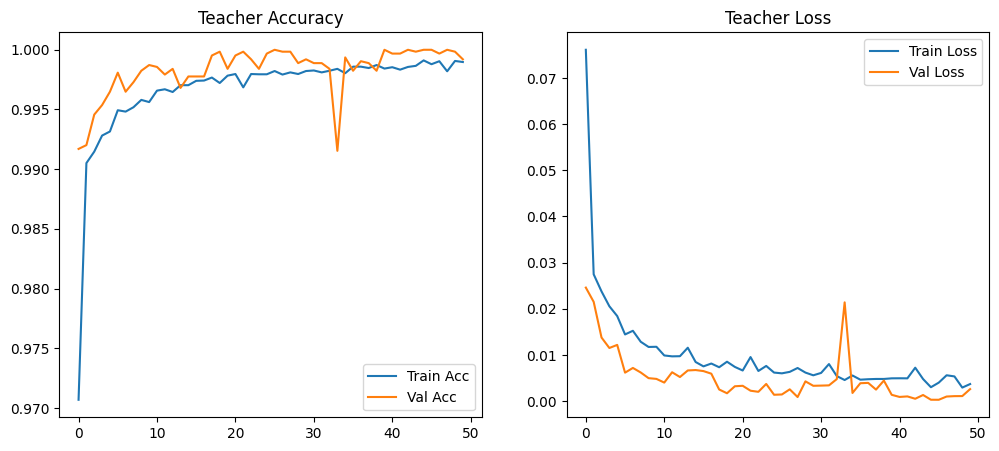

392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9984 - loss: 0.0046



🏆 Final Expert Accuracy: 99.84%
💾 Expert Model saved as 'teacher_model.h5'


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib  # Used to export the scaler math for future use
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- STEP 1: LOAD AND CLEAN ---
# We load the data and immediately drop the "Leakage" columns (Time/Index)
# identified in our EDA to ensure the model learns physics, not timestamps.
df = pd.read_csv('smoke_detection_iot.csv')
features = ['Humidity[%]', 'Pressure[hPa]', 'Raw H2', 'NC2.5', 'NC1.0',
            'PM2.5', 'eCO2[ppm]', 'PM1.0', 'NC0.5', 'Temperature[C]',
            'TVOC[ppb]', 'Raw Ethanol']
X = df[features]
y = df['Fire Alarm']

# --- STEP 2: DATA SPLITTING ---
# We split into 80% Training, 10% Validation (for tuning), and 10% Testing (final exam).
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.125, random_state=42)

# --- STEP 3: FEATURE SCALING ---
# We "Standardize" the data so all sensors have a mean of 0 and variance of 1.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# EXPORT SCALER: We save these math constants to use in Phase 2 and on the ESP32.
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler constants saved to 'scaler.pkl'")

# --- STEP 4: DESIGN THE TEACHER ---
# This is a "Heavy" model with ~30,000+ parameters.
# It is designed to be the "Expert" that the tiny model will eventually mimic.
teacher_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(len(features),)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Randomly shuts off 20% of neurons to prevent memorization
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Outputs a probability between 0 and 1
])

teacher_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- STEP 5: MONITORING & TRAINING ---
# CSVLogger records the loss/accuracy of every epoch so we can audit the progress later.
csv_logger = tf.keras.callbacks.CSVLogger('training_log.csv', append=False)

print("🚀 Starting Teacher Training...")
history = teacher_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[csv_logger],
    verbose=1
)

# --- STEP 6: VISUALIZATION ---
# We plot the curves to ensure the "Orange" (Val) line follows the "Blue" (Train) line.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Teacher Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Teacher Loss')
plt.legend()
plt.show()

# --- STEP 7: FINAL EXAM & SAVE ---
loss, accuracy = teacher_model.evaluate(X_test, y_test)
print(f"\n🏆 Final Expert Accuracy: {accuracy*100:.2f}%")

teacher_model.save('teacher_model.h5')
print("💾 Expert Model saved as 'teacher_model.h5'")